# Bike Rental Demand Analysis

This notebook:

- Loads direct and registered bike rentals
- Performs exploratory time-series analysis
- Compares rental behavior patterns
- Merges weather and holiday information
- Builds an hourly forecasting-ready dataset

Goal:

Predict hourly bike demand using:

- Time features
- Weather conditions
- Holidays
- Rental behavior patterns

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Helper Functions

Reusable utility functions for:
- Feature engineering
- Aggregation
- Plotting
- Dataset summaries

In [54]:
def load_rentals(path, rental_type_direct):

    df = pd.read_csv(path)

    df["datetime"] = pd.to_datetime(df["datetime"])

    df["rental_type_direct"] = rental_type_direct

    return df

In [55]:
def add_time_features(df):

    df = df.copy()

    df["year"] = df["datetime"].dt.year
    df["month"] = df["datetime"].dt.month
    df["day"] = df["datetime"].dt.day
    df["hour"] = df["datetime"].dt.hour

    df["weekday"] = df["datetime"].dt.day_name()

    df["week"] = df["datetime"].dt.isocalendar().week

    df["is_weekend"] = df["datetime"].dt.weekday >= 5

    return df

In [56]:
def create_hourly_features(df):

    hourly = (
        df.groupby(pd.Grouper(key="datetime", freq="h"))
        .size()
        .reset_index(name="rental_count")
    )

    return add_time_features(hourly)

In [57]:
def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    return "Fall"

In [58]:
def add_season(df):

    df["season"] = df["month"].apply(get_season)

    return df

In [59]:
def dataset_summary(name, df):

    print(f"\n{name}")
    print("-" * 40)

    print(f"Shape: {df.shape}")

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nNull Counts:")
    print(df.isnull().sum())

    print("\nData types:")
    print(df.dtypes)

    print("\nDuplicate rows:")
    print(df.duplicated().sum())

    display(df.head())

# Load Rental Datasets
Two datasets are available:
- Direct bike pickups
- Registered bike rentals

A binary column identifies rental type:
- 1 → Direct rental
- 0 → Registered rental

In [60]:
direct_rentals_df = load_rentals(
    "../week-2/data/direct_pickup_bike_rentals.csv", rental_type_direct=1
)

registered_rentals_df = load_rentals(
    "../week-2/data/registered_bike_rentals.csv", rental_type_direct=0
)

dataset_summary("Direct Rentals", direct_rentals_df)

dataset_summary("Registered Rentals", registered_rentals_df)


Direct Rentals
----------------------------------------
Shape: (620017, 5)

Columns:
['id', 'datetime', 'user_id', 'location_id', 'rental_type_direct']

Null Counts:
id                    0
datetime              0
user_id               0
location_id           0
rental_type_direct    0
dtype: int64

Data types:
id                             int64
datetime              datetime64[ns]
user_id                        int64
location_id                    int64
rental_type_direct             int64
dtype: object

Duplicate rows:
0


,id,datetime,user_id,location_id,rental_type_direct
0,1,2011-01-01 00:24:04,232,2,1
1,2,2011-01-01 00:30:19,54,14,1
2,3,2011-01-01 00:39:08,201,5,1
3,4,2011-01-01 01:01:12,298,13,1
4,5,2011-01-01 01:02:37,23,14,1



Registered Rentals
----------------------------------------
Shape: (2672662, 5)

Columns:
['id', 'datetime', 'user_id', 'location_id', 'rental_type_direct']

Null Counts:
id                    0
datetime              0
user_id               0
location_id           0
rental_type_direct    0
dtype: int64

Data types:
id                             int64
datetime              datetime64[ns]
user_id                        int64
location_id                    int64
rental_type_direct             int64
dtype: object

Duplicate rows:
0


,id,datetime,user_id,location_id,rental_type_direct
0,1,2011-01-01 00:05:09,158,16,0
1,2,2011-01-01 00:05:21,262,18,0
2,3,2011-01-01 00:05:39,68,18,0
3,4,2011-01-01 00:12:05,12,9,0
4,5,2011-01-01 00:25:58,91,11,0


# Add Time Features
Extract useful datetime information:
- Year
- Month
- Day
- Hour
- Weekday
- Week number
- Weekend flag

# Combine Datasets
Merge both rental datasets into one unified dataframe.

In [61]:
direct_rentals_df = add_time_features(direct_rentals_df)

registered_rentals_df = add_time_features(registered_rentals_df)

In [62]:
df = pd.concat([direct_rentals_df, registered_rentals_df], ignore_index=True)

dataset_summary("Combined Rentals", df)

print("\nDuplicate rows:", df.duplicated().sum())


Combined Rentals
----------------------------------------
Shape: (3292679, 12)

Columns:
['id', 'datetime', 'user_id', 'location_id', 'rental_type_direct', 'year', 'month', 'day', 'hour', 'weekday', 'week', 'is_weekend']

Null Counts:
id                    0
datetime              0
user_id               0
location_id           0
rental_type_direct    0
year                  0
month                 0
day                   0
hour                  0
weekday               0
week                  0
is_weekend            0
dtype: int64

Data types:
id                             int64
datetime              datetime64[ns]
user_id                        int64
location_id                    int64
rental_type_direct             int64
year                           int32
month                          int32
day                            int32
hour                           int32
weekday                       object
week                          UInt32
is_weekend                      bool
dtype:

,id,datetime,user_id,location_id,rental_type_direct,year,month,day,hour,weekday,week,is_weekend
0,1,2011-01-01 00:24:04,232,2,1,2011,1,1,0,Saturday,52,True
1,2,2011-01-01 00:30:19,54,14,1,2011,1,1,0,Saturday,52,True
2,3,2011-01-01 00:39:08,201,5,1,2011,1,1,0,Saturday,52,True
3,4,2011-01-01 01:01:12,298,13,1,2011,1,1,1,Saturday,52,True
4,5,2011-01-01 01:02:37,23,14,1,2011,1,1,1,Saturday,52,True



Duplicate rows: 0


# Create Hourly Aggregations
Aggregate rentals into hourly demand counts.
This becomes the primary forecasting target.

In [63]:
hourly_combined = create_hourly_features(df)

hourly_direct = create_hourly_features(direct_rentals_df)

hourly_registered = create_hourly_features(registered_rentals_df)

datasets = [
    ("Combined", hourly_combined),
    ("Direct", hourly_direct),
    ("Registered", hourly_registered),
]

# Rental Distribution
Compare overall rental share between:
- Direct rentals
- Registered rentals

Total Rentals: 3,292,679
Direct Rentals: 620,017 (18.83%)
Registered Rentals: 2,672,662 (81.17%)


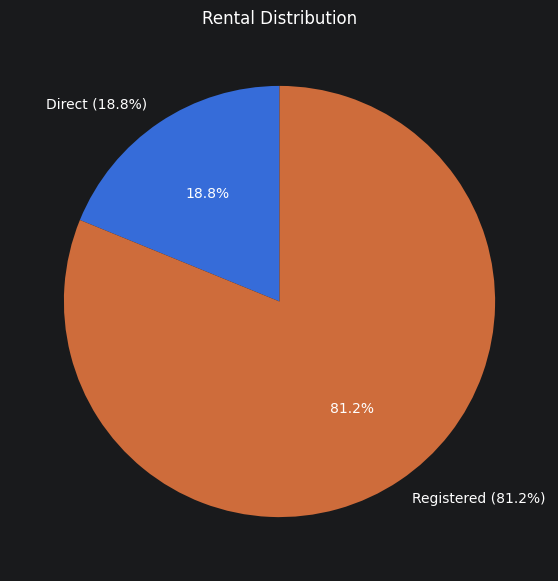

In [64]:
direct_count = len(direct_rentals_df)

registered_count = len(registered_rentals_df)

total_count = direct_count + registered_count

direct_pct = (direct_count / total_count) * 100

registered_pct = (registered_count / total_count) * 100

print(f"Total Rentals: {total_count:,}")

print(f"Direct Rentals: {direct_count:,} ({direct_pct:.2f}%)")

print(f"Registered Rentals: {registered_count:,} ({registered_pct:.2f}%)")

plt.figure(figsize=(7, 7))

plt.pie(
    [direct_count, registered_count],
    labels=[
        f"Direct ({direct_pct:.1f}%)",
        f"Registered ({registered_pct:.1f}%)",
    ],
    autopct="%1.1f%%",
    startangle=90,
)

plt.title("Rental Distribution")

plt.show()

# Generic Comparison Plot Function
Reusable plotting function for:
- Hourly
- Weekly
- Monthly
- Seasonal comparisons

In [65]:
def compare_patterns(datasets, group_col, title, kind="line", order=None):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

    for ax, (name, dataset) in zip(axes, datasets):
        pattern = (
            dataset.groupby(group_col)["rental_count"].mean().reset_index()
        )

        if order is not None:
            pattern[group_col] = pd.Categorical(
                pattern[group_col], categories=order, ordered=True
            )

            pattern = pattern.sort_values(group_col)

        if kind == "line":
            sns.lineplot(
                data=pattern, x=group_col, y="rental_count", marker="o", ax=ax
            )

        else:
            sns.barplot(data=pattern, x=group_col, y="rental_count", ax=ax)

        ax.set_title(f"{name} {title}")

    plt.tight_layout()
    plt.show()

# Hourly Rental Patterns
Analyze demand fluctuations throughout the day.
Expected:
- Morning commute peaks
- Evening commute peaks
- Lower overnight demand

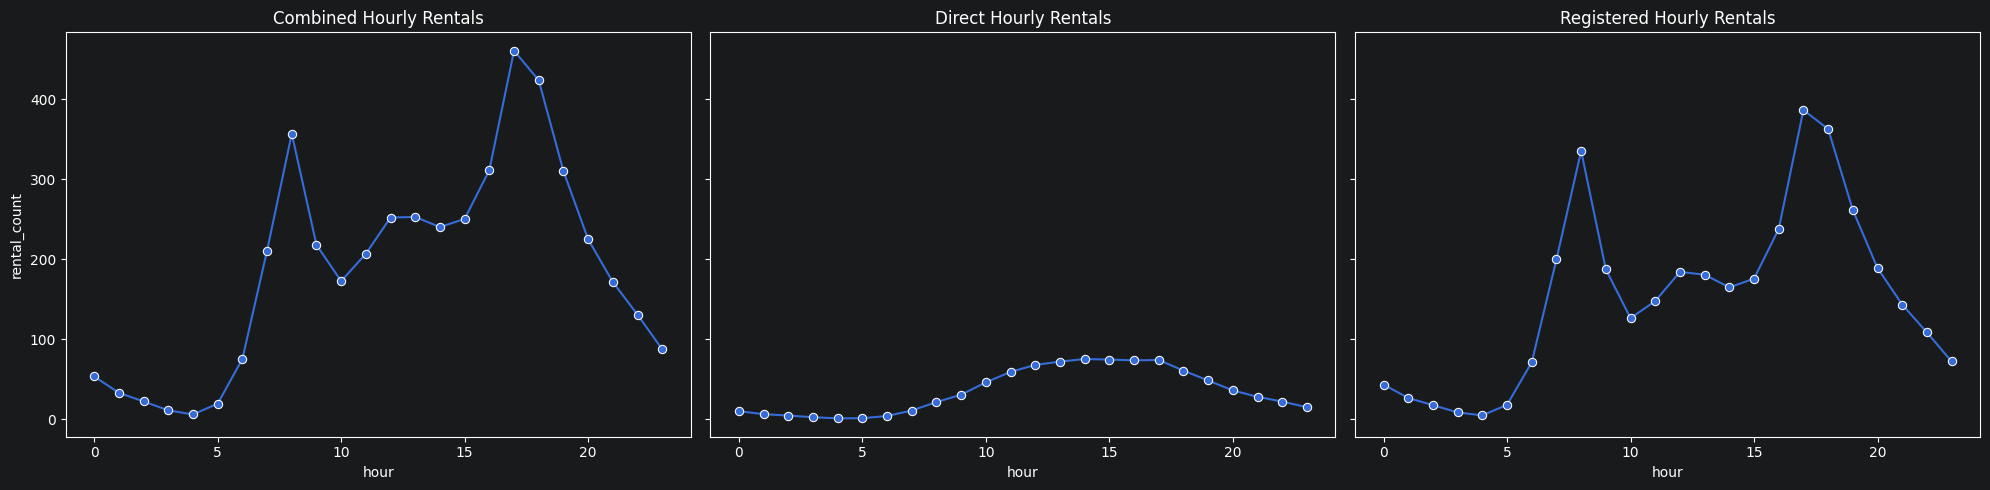

In [66]:
compare_patterns(
    datasets, group_col="hour", title="Hourly Rentals", kind="line"
)

# Weekly Rental Patterns
Compare weekday versus weekend behavior.

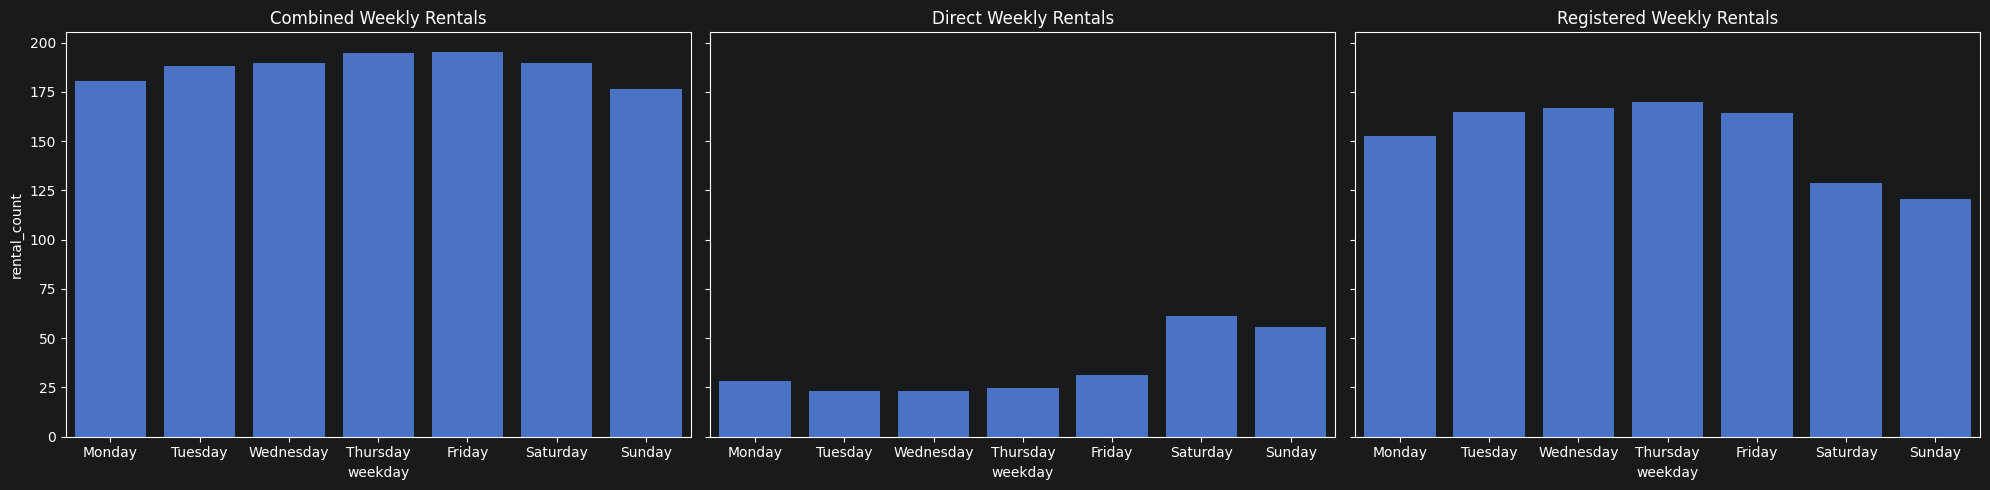

In [67]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

compare_patterns(
    datasets,
    group_col="weekday",
    title="Weekly Rentals",
    kind="bar",
    order=weekday_order,
)

# Monthly Rental Trends
Analyze long-term seasonal changes throughout the year.

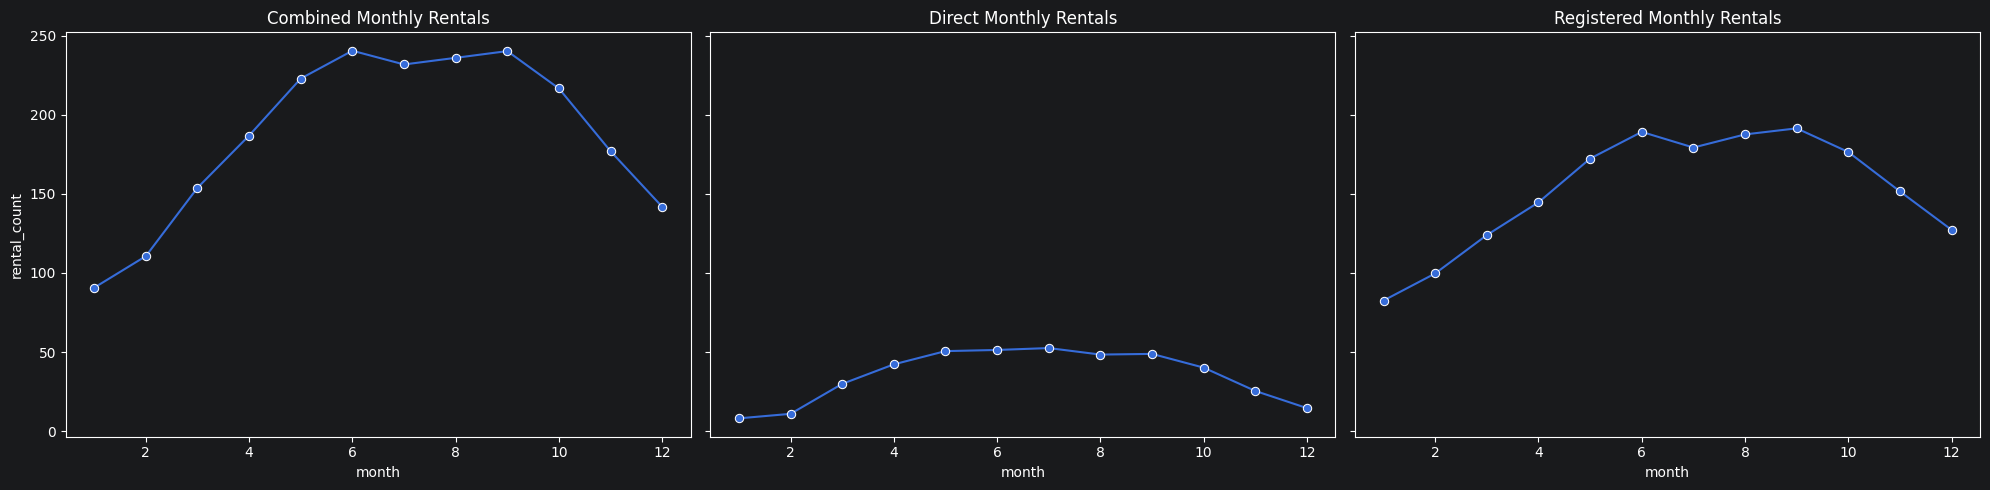

In [68]:
compare_patterns(
    datasets, group_col="month", title="Monthly Rentals", kind="line"
)

# Seasonal Rental Patterns
Compare rental demand across:
- Winter
- Spring
- Summer
- Fall

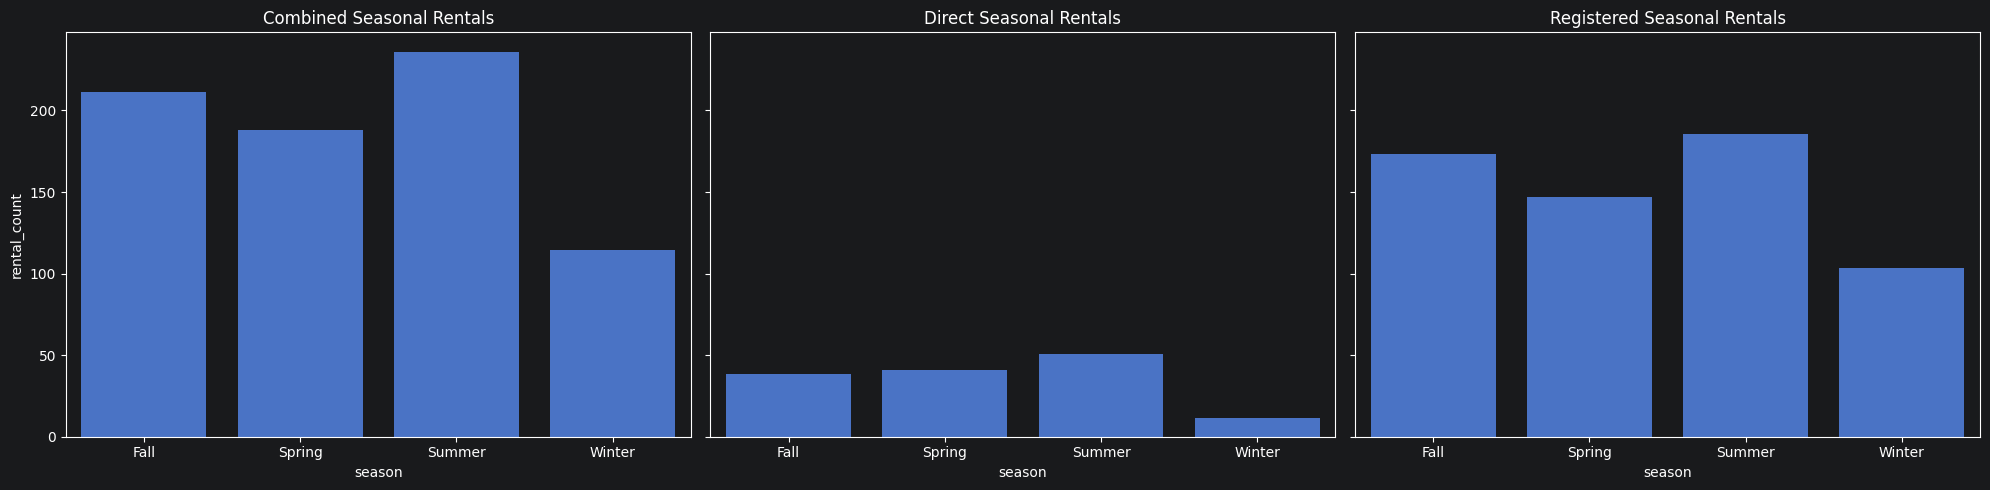

In [69]:
hourly_combined = add_season(hourly_combined)

hourly_direct = add_season(hourly_direct)

hourly_registered = add_season(hourly_registered)

datasets = [
    ("Combined", hourly_combined),
    ("Direct", hourly_direct),
    ("Registered", hourly_registered),
]

compare_patterns(
    datasets, group_col="season", title="Seasonal Rentals", kind="bar"
)

# Daily Demand Trends
Observe long-term fluctuations in total daily demand.

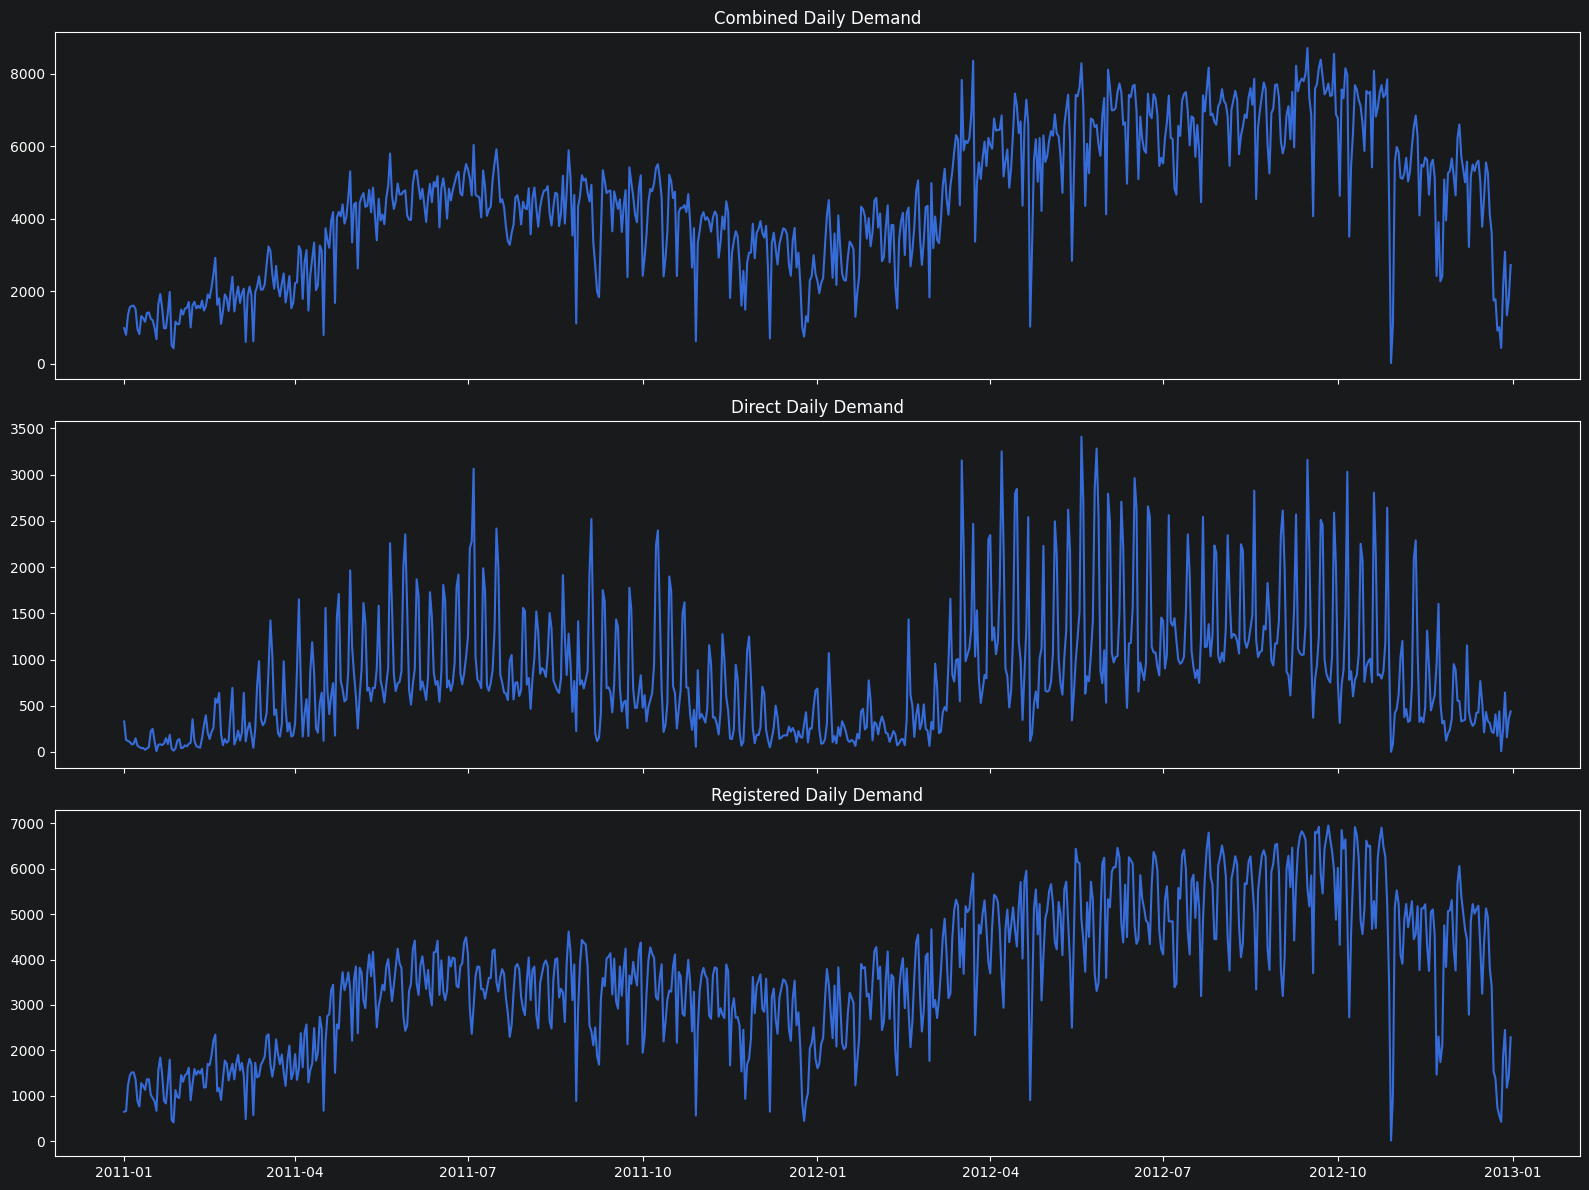

In [70]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for ax, (name, dataset) in zip(axes, datasets):
    daily = (
        dataset.groupby(dataset["datetime"].dt.date)["rental_count"]
        .sum()
        .reset_index()
    )

    daily.columns = ["date", "daily_total"]

    ax.plot(daily["date"], daily["daily_total"])

    ax.set_title(f"{name} Daily Demand")

plt.tight_layout()
plt.show()

# Demand Heatmaps
Visualize hourly demand intensity across weekdays.

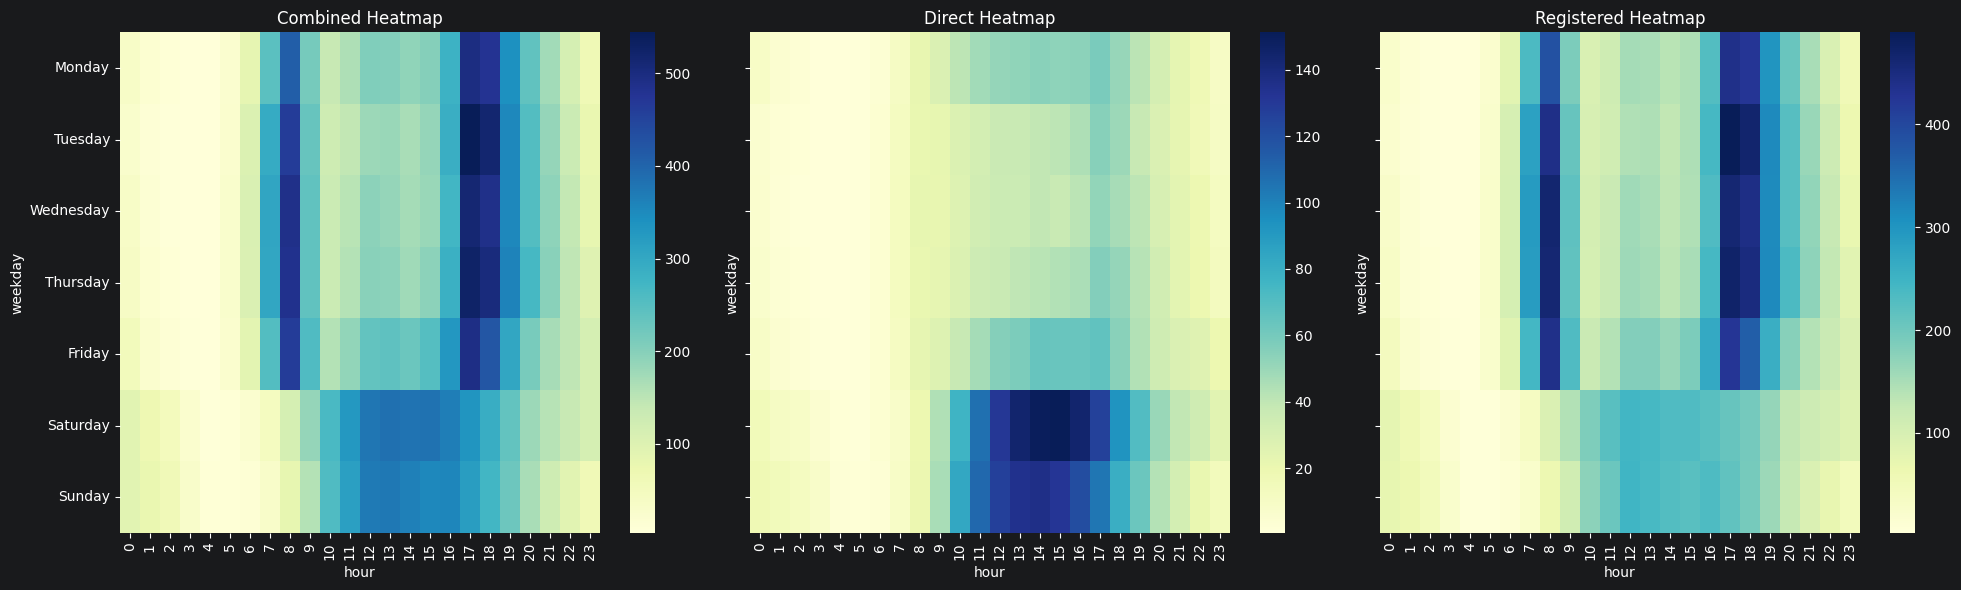

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, (name, dataset) in zip(axes, datasets):
    pivot = (
        dataset.groupby(["weekday", "hour"])["rental_count"]
        .mean()
        .reset_index()
    )

    pivot_table = pivot.pivot(
        index="weekday", columns="hour", values="rental_count"
    )

    pivot_table = pivot_table.reindex(weekday_order)

    sns.heatmap(pivot_table, cmap="YlGnBu", ax=ax)

    ax.set_title(f"{name} Heatmap")

plt.tight_layout()
plt.show()

# Weather and Holiday Data
Load external datasets:
- Weather conditions
- Public holidays
These features improve forecasting accuracy.

In [102]:
weather_df = pd.read_csv("../week-2/data/weather.csv")

weather_df["datetime"] = pd.to_datetime(weather_df["datetime"])

weather_df["datetime_hour"] = weather_df["datetime"].dt.floor("h")

dataset_summary("Weather Dataset", weather_df)


Weather Dataset
----------------------------------------
Shape: (17379, 8)

Columns:
['id', 'datetime', 'conditions', 'temperature_c', 'perceived_temperature_c', 'humidity', 'windspeed_kmh', 'datetime_hour']

Null Counts:
id                         0
datetime                   0
conditions                 0
temperature_c              0
perceived_temperature_c    0
humidity                   0
windspeed_kmh              0
datetime_hour              0
dtype: int64

Data types:
id                                  int64
datetime                   datetime64[ns]
conditions                         object
temperature_c                     float64
perceived_temperature_c           float64
humidity                          float64
windspeed_kmh                     float64
datetime_hour              datetime64[ns]
dtype: object

Duplicate rows:
0


,id,datetime,conditions,temperature_c,perceived_temperature_c,humidity,windspeed_kmh,datetime_hour
0,1,2011-01-01 00:00:00,clear,3.3,3.0,81.0,0.0,2011-01-01 00:00:00
1,2,2011-01-01 01:00:00,clear,2.3,2.0,80.0,0.0,2011-01-01 01:00:00
2,3,2011-01-01 02:00:00,clear,2.3,2.0,80.0,0.0,2011-01-01 02:00:00
3,4,2011-01-01 03:00:00,clear,3.3,3.0,75.0,0.0,2011-01-01 03:00:00
4,5,2011-01-01 04:00:00,clear,3.3,3.0,75.0,0.0,2011-01-01 04:00:00


In [73]:
holidays_df = pd.read_csv("../week-2/data/holidays.csv")

holidays_df["date"] = pd.to_datetime(holidays_df["date"])

dataset_summary("Holiday Dataset", holidays_df)


Holiday Dataset
----------------------------------------
Shape: (21, 3)

Columns:
['id', 'date', 'holiday']

Null Counts:
id         0
date       0
holiday    0
dtype: int64

Data types:
id                  int64
date       datetime64[ns]
holiday            object
dtype: object

Duplicate rows:
0


,id,date,holiday
0,1,2011-01-17,"Dr. Martin Luther King, Jr.'s Birthday"
1,2,2011-02-21,Washington's Birthday
2,3,2011-04-15,D.C. Emancipation Day (observed)
3,4,2011-05-30,Memorial Day
4,5,2011-07-04,Independence Day


In [74]:
df["datetime_hour"] = df["datetime"].dt.floor("h")

df["date"] = df["datetime"].dt.floor("d")

# Merge Weather Data
Left join preserves all rental records.
Weather information is matched hourly.

In [75]:
rentals_weather_df = df.merge(
    weather_df[
        [
            "datetime_hour",
            "conditions",
            "temperature_c",
            "perceived_temperature_c",
            "humidity",
            "windspeed_kmh",
        ]
    ],
    on="datetime_hour",
    how="left",
)

dataset_summary("Rentals + Weather", rentals_weather_df)


Rentals + Weather
----------------------------------------
Shape: (3292679, 19)

Columns:
['id', 'datetime', 'user_id', 'location_id', 'rental_type_direct', 'year', 'month', 'day', 'hour', 'weekday', 'week', 'is_weekend', 'datetime_hour', 'date', 'conditions', 'temperature_c', 'perceived_temperature_c', 'humidity', 'windspeed_kmh']

Null Counts:
id                         0
datetime                   0
user_id                    0
location_id                0
rental_type_direct         0
year                       0
month                      0
day                        0
hour                       0
weekday                    0
week                       0
is_weekend                 0
datetime_hour              0
date                       0
conditions                 0
temperature_c              0
perceived_temperature_c    0
humidity                   0
windspeed_kmh              0
dtype: int64

Data types:
id                                  int64
datetime                   datet

,id,datetime,user_id,location_id,rental_type_direct,year,month,day,hour,weekday,week,is_weekend,datetime_hour,date,conditions,temperature_c,perceived_temperature_c,humidity,windspeed_kmh
0,1,2011-01-01 00:24:04,232,2,1,2011,1,1,0,Saturday,52,True,2011-01-01 00:00:00,2011-01-01,clear,3.3,3.0,81.0,0.0
1,2,2011-01-01 00:30:19,54,14,1,2011,1,1,0,Saturday,52,True,2011-01-01 00:00:00,2011-01-01,clear,3.3,3.0,81.0,0.0
2,3,2011-01-01 00:39:08,201,5,1,2011,1,1,0,Saturday,52,True,2011-01-01 00:00:00,2011-01-01,clear,3.3,3.0,81.0,0.0
3,4,2011-01-01 01:01:12,298,13,1,2011,1,1,1,Saturday,52,True,2011-01-01 01:00:00,2011-01-01,clear,2.3,2.0,80.0,0.0
4,5,2011-01-01 01:02:37,23,14,1,2011,1,1,1,Saturday,52,True,2011-01-01 01:00:00,2011-01-01,clear,2.3,2.0,80.0,0.0


# Merge Holiday Data
Join holidays by calendar date.
Left join ensures:
- all rentals remain
- non-holidays become null

In [76]:
final_df = rentals_weather_df.merge(
    holidays_df[["date", "holiday"]], on="date", how="left"
)

final_df["is_holiday"] = final_df["holiday"].notna().astype(int)

dataset_summary("Final Dataset", final_df)

print(final_df.head())


Final Dataset
----------------------------------------
Shape: (3292679, 21)

Columns:
['id', 'datetime', 'user_id', 'location_id', 'rental_type_direct', 'year', 'month', 'day', 'hour', 'weekday', 'week', 'is_weekend', 'datetime_hour', 'date', 'conditions', 'temperature_c', 'perceived_temperature_c', 'humidity', 'windspeed_kmh', 'holiday', 'is_holiday']

Null Counts:
id                               0
datetime                         0
user_id                          0
location_id                      0
rental_type_direct               0
year                             0
month                            0
day                              0
hour                             0
weekday                          0
week                             0
is_weekend                       0
datetime_hour                    0
date                             0
conditions                       0
temperature_c                    0
perceived_temperature_c          0
humidity                         0


,id,datetime,user_id,location_id,rental_type_direct,year,month,day,hour,weekday,...,is_weekend,datetime_hour,date,conditions,temperature_c,perceived_temperature_c,humidity,windspeed_kmh,holiday,is_holiday
0,1,2011-01-01 00:24:04,232,2,1,2011,1,1,0,Saturday,...,True,2011-01-01 00:00:00,2011-01-01,clear,3.3,3.0,81.0,0.0,NaN,0
1,2,2011-01-01 00:30:19,54,14,1,2011,1,1,0,Saturday,...,True,2011-01-01 00:00:00,2011-01-01,clear,3.3,3.0,81.0,0.0,NaN,0
2,3,2011-01-01 00:39:08,201,5,1,2011,1,1,0,Saturday,...,True,2011-01-01 00:00:00,2011-01-01,clear,3.3,3.0,81.0,0.0,NaN,0
3,4,2011-01-01 01:01:12,298,13,1,2011,1,1,1,Saturday,...,True,2011-01-01 01:00:00,2011-01-01,clear,2.3,2.0,80.0,0.0,NaN,0
4,5,2011-01-01 01:02:37,23,14,1,2011,1,1,1,Saturday,...,True,2011-01-01 01:00:00,2011-01-01,clear,2.3,2.0,80.0,0.0,NaN,0


   id            datetime  user_id  location_id  rental_type_direct  year  \
0   1 2011-01-01 00:24:04      232            2                   1  2011   
1   2 2011-01-01 00:30:19       54           14                   1  2011   
2   3 2011-01-01 00:39:08      201            5                   1  2011   
3   4 2011-01-01 01:01:12      298           13                   1  2011   
4   5 2011-01-01 01:02:37       23           14                   1  2011   

   month  day  hour   weekday  ...  is_weekend       datetime_hour       date  \
0      1    1     0  Saturday  ...        True 2011-01-01 00:00:00 2011-01-01   
1      1    1     0  Saturday  ...        True 2011-01-01 00:00:00 2011-01-01   
2      1    1     0  Saturday  ...        True 2011-01-01 00:00:00 2011-01-01   
3      1    1     1  Saturday  ...        True 2011-01-01 01:00:00 2011-01-01   
4      1    1     1  Saturday  ...        True 2011-01-01 01:00:00 2011-01-01   

  conditions temperature_c  perceived_temperature_

# Build Forecasting Dataset
Aggregate all information into hourly observations.
Final features include:
- Demand
- Weather
- Holiday indicators
- Rental type distributions

In [77]:
hourly_features_df = (
    final_df.groupby("datetime_hour")
    .agg(
        rental_count=("id", "count"),
        direct_rentals=("rental_type_direct", "sum"),
        registered_rentals=("rental_type_direct", lambda x: (x == 0).sum()),
        temperature_c=("temperature_c", "mean"),
        perceived_temperature_c=("perceived_temperature_c", "mean"),
        humidity=("humidity", "mean"),
        windspeed_kmh=("windspeed_kmh", "mean"),
        conditions=("conditions", "first"),
        holiday=("holiday", "first"),
        is_holiday=("is_holiday", "max"),
    )
    .reset_index()
)

dataset_summary("Hourly Forecast Dataset", hourly_features_df)

hourly_features_df.head()


Hourly Forecast Dataset
----------------------------------------
Shape: (17379, 11)

Columns:
['datetime_hour', 'rental_count', 'direct_rentals', 'registered_rentals', 'temperature_c', 'perceived_temperature_c', 'humidity', 'windspeed_kmh', 'conditions', 'holiday', 'is_holiday']

Null Counts:
datetime_hour                  0
rental_count                   0
direct_rentals                 0
registered_rentals             0
temperature_c                  0
perceived_temperature_c        0
humidity                       0
windspeed_kmh                  0
conditions                     0
holiday                    16879
is_holiday                     0
dtype: int64

Data types:
datetime_hour              datetime64[ns]
rental_count                        int64
direct_rentals                      int64
registered_rentals                  int64
temperature_c                     float64
perceived_temperature_c           float64
humidity                          float64
windspeed_kmh         

,datetime_hour,rental_count,direct_rentals,registered_rentals,temperature_c,perceived_temperature_c,humidity,windspeed_kmh,conditions,holiday,is_holiday
0,2011-01-01 00:00:00,16,3,13,3.3,3.0,81.0,0.0,clear,None,0
1,2011-01-01 01:00:00,40,8,32,2.3,2.0,80.0,0.0,clear,None,0
2,2011-01-01 02:00:00,32,5,27,2.3,2.0,80.0,0.0,clear,None,0
3,2011-01-01 03:00:00,13,3,10,3.3,3.0,75.0,0.0,clear,None,0
4,2011-01-01 04:00:00,1,0,1,3.3,3.0,75.0,0.0,clear,None,0


,datetime_hour,rental_count,direct_rentals,registered_rentals,temperature_c,perceived_temperature_c,humidity,windspeed_kmh,conditions,holiday,is_holiday
0,2011-01-01 00:00:00,16,3,13,3.3,3.0,81.0,0.0,clear,None,0
1,2011-01-01 01:00:00,40,8,32,2.3,2.0,80.0,0.0,clear,None,0
2,2011-01-01 02:00:00,32,5,27,2.3,2.0,80.0,0.0,clear,None,0
3,2011-01-01 03:00:00,13,3,10,3.3,3.0,75.0,0.0,clear,None,0
4,2011-01-01 04:00:00,1,0,1,3.3,3.0,75.0,0.0,clear,None,0


# Ignore

In [78]:
direct_rentals = pd.read_csv("../week-2/data/direct_pickup_bike_rentals.csv")

print(f"Shape {direct_rentals.shape}")
print(f"Columns {direct_rentals.columns}")
print("Null counts :")
print(direct_rentals.isnull().sum())

# Ensure datetime column exists with right datatype
if "datetime" in direct_rentals.columns:
    direct_rentals["datetime"] = pd.to_datetime(direct_rentals["datetime"])

Shape (620017, 4)
Columns Index(['id', 'datetime', 'user_id', 'location_id'], dtype='object')
Null counts :
id             0
datetime       0
user_id        0
location_id    0
dtype: int64


In [79]:
direct_rentals_df = direct_rentals.copy()

direct_rentals_df["year"] = direct_rentals_df["datetime"].dt.year
direct_rentals_df["month"] = direct_rentals_df["datetime"].dt.month
direct_rentals_df["day"] = direct_rentals_df["datetime"].dt.day
direct_rentals_df["hour"] = direct_rentals_df["datetime"].dt.hour
direct_rentals_df["weekday"] = direct_rentals_df["datetime"].dt.day_name()
direct_rentals_df["week"] = direct_rentals_df["datetime"].dt.isocalendar().week

print(f"Shape {direct_rentals_df.shape}")
print(direct_rentals_df.head())
print("\nData types:")
print(direct_rentals_df.dtypes)

Shape (620017, 10)
   id            datetime  user_id  location_id  year  month  day  hour  \
0   1 2011-01-01 00:24:04      232            2  2011      1    1     0   
1   2 2011-01-01 00:30:19       54           14  2011      1    1     0   
2   3 2011-01-01 00:39:08      201            5  2011      1    1     0   
3   4 2011-01-01 01:01:12      298           13  2011      1    1     1   
4   5 2011-01-01 01:02:37       23           14  2011      1    1     1   

    weekday  week  
0  Saturday    52  
1  Saturday    52  
2  Saturday    52  
3  Saturday    52  
4  Saturday    52  

Data types:
id                      int64
datetime       datetime64[ns]
user_id                 int64
location_id             int64
year                    int32
month                   int32
day                     int32
hour                    int32
weekday                object
week                   UInt32
dtype: object


About Direct rentals data



In [80]:
registered_rentals = pd.read_csv("../week-2/data/registered_bike_rentals.csv")


print(f"Shape {registered_rentals.shape}")
print(f"Columns {registered_rentals.columns}")
print("Null counts :")
print(registered_rentals.isnull().sum())

# Ensure datetime column exists
if "datetime" in registered_rentals.columns:
    registered_rentals["datetime"] = pd.to_datetime(
        registered_rentals["datetime"]
    )

Shape (2672662, 4)
Columns Index(['id', 'datetime', 'user_id', 'location_id'], dtype='object')
Null counts :
id             0
datetime       0
user_id        0
location_id    0
dtype: int64


In [81]:
registered_rentals_df = registered_rentals.copy()

# Extract time components
registered_rentals_df["year"] = registered_rentals_df["datetime"].dt.year
registered_rentals_df["month"] = registered_rentals_df["datetime"].dt.month
registered_rentals_df["day"] = registered_rentals_df["datetime"].dt.day
registered_rentals_df["hour"] = registered_rentals_df["datetime"].dt.hour
registered_rentals_df["weekday"] = registered_rentals_df[
    "datetime"
].dt.day_name()
registered_rentals_df["week"] = (
    registered_rentals_df["datetime"].dt.isocalendar().week
)


print(f"Shape {registered_rentals_df.shape}")
print(registered_rentals_df.head())
print("\nData types:")
print(registered_rentals_df.dtypes)

Shape (2672662, 10)
   id            datetime  user_id  location_id  year  month  day  hour  \
0   1 2011-01-01 00:05:09      158           16  2011      1    1     0   
1   2 2011-01-01 00:05:21      262           18  2011      1    1     0   
2   3 2011-01-01 00:05:39       68           18  2011      1    1     0   
3   4 2011-01-01 00:12:05       12            9  2011      1    1     0   
4   5 2011-01-01 00:25:58       91           11  2011      1    1     0   

    weekday  week  
0  Saturday    52  
1  Saturday    52  
2  Saturday    52  
3  Saturday    52  
4  Saturday    52  

Data types:
id                      int64
datetime       datetime64[ns]
user_id                 int64
location_id             int64
year                    int32
month                   int32
day                     int32
hour                    int32
weekday                object
week                   UInt32
dtype: object


About registered rentals data

Aggregate, group by hours

time series forecasting

weekly patterns
monthly patterns
seasonal patterns
look at distributions per day, per month, per season, compare the same days, months, seasons from 2011 to 2012

In [82]:
direct_rentals["rental_type_direct"] = 1
registered_rentals["rental_type_direct"] = 0

df = pd.concat([direct_rentals, registered_rentals], ignore_index=True)

print(f"Shape {df.shape}")
print(df.head())
print("\nData types:")
print(df.dtypes)

print("\nDuplicate rows:")
print(df.duplicated().sum())

Shape (3292679, 5)
   id            datetime  user_id  location_id  rental_type_direct
0   1 2011-01-01 00:24:04      232            2                   1
1   2 2011-01-01 00:30:19       54           14                   1
2   3 2011-01-01 00:39:08      201            5                   1
3   4 2011-01-01 01:01:12      298           13                   1
4   5 2011-01-01 01:02:37       23           14                   1

Data types:
id                             int64
datetime              datetime64[ns]
user_id                        int64
location_id                    int64
rental_type_direct             int64
dtype: object

Duplicate rows:
0


In [83]:
def create_hourly_features(input_df):

    hourly = (
        input_df.groupby(pd.Grouper(key="datetime", freq="h"))
        .size()
        .reset_index(name="rental_count")
    )

    hourly["year"] = hourly["datetime"].dt.year
    hourly["month"] = hourly["datetime"].dt.month
    hourly["day"] = hourly["datetime"].dt.day
    hourly["hour"] = hourly["datetime"].dt.hour

    hourly["weekday"] = hourly["datetime"].dt.day_name()

    hourly["week"] = hourly["datetime"].dt.isocalendar().week

    hourly["is_weekend"] = hourly["datetime"].dt.weekday >= 5

    return hourly


hourly_combined = create_hourly_features(df)

hourly_direct = create_hourly_features(direct_rentals_df)

hourly_registered = create_hourly_features(registered_rentals_df)

Total rentals: 3,292,679
Direct rentals: 620,017 (18.83%)
Registered rentals: 2,672,662 (81.17%)


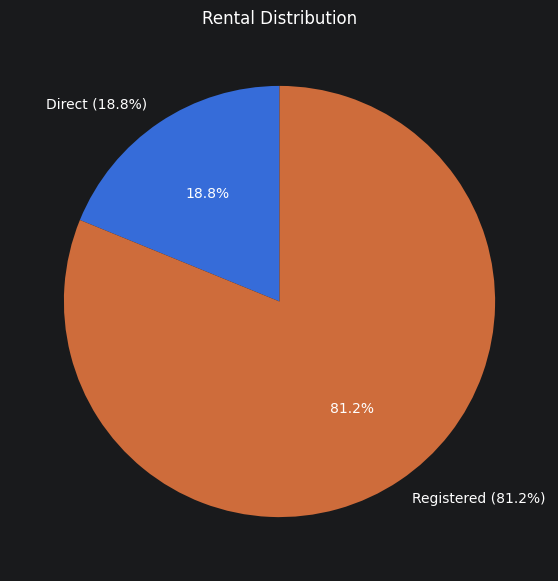

In [84]:
direct_count = len(direct_rentals_df)
registered_count = len(registered_rentals_df)

total_count = direct_count + registered_count

direct_pct = (direct_count / total_count) * 100

registered_pct = (registered_count / total_count) * 100

print(f"Total rentals: {total_count:,}")

print(f"Direct rentals: {direct_count:,} ({direct_pct:.2f}%)")

print(f"Registered rentals: {registered_count:,} ({registered_pct:.2f}%)")

plt.figure(figsize=(7, 7))

plt.pie(
    [direct_count, registered_count],
    labels=[
        f"Direct ({direct_pct:.1f}%)",
        f"Registered ({registered_pct:.1f}%)",
    ],
    autopct="%1.1f%%",
    startangle=90,
)

plt.title("Rental Distribution")

plt.show()

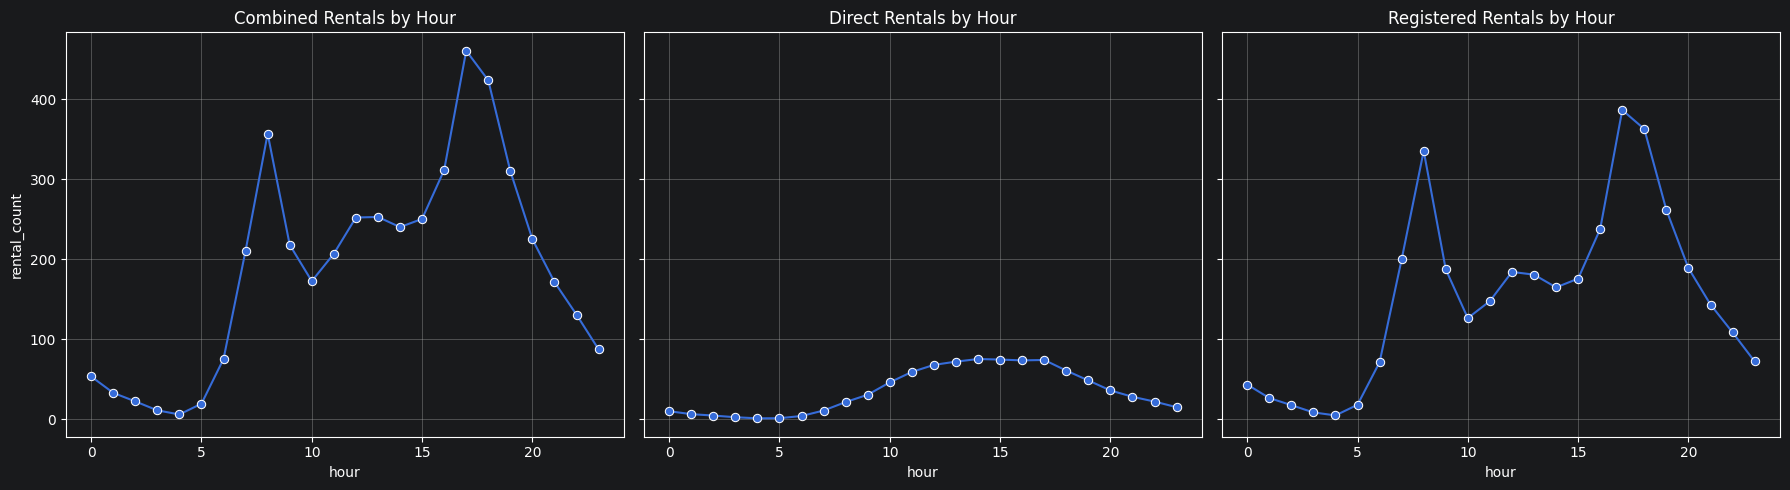

In [85]:
datasets = [
    ("Combined", hourly_combined),
    ("Direct", hourly_direct),
    ("Registered", hourly_registered),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (title, dataset) in zip(axes, datasets):
    pattern = dataset.groupby("hour")["rental_count"].mean().reset_index()

    sns.lineplot(data=pattern, x="hour", y="rental_count", marker="o", ax=ax)

    ax.set_title(f"{title} Rentals by Hour")
    ax.grid(True)

plt.tight_layout()
plt.show()

# Rentals by hour

Direct rentals are normally distributed throughout the day from 7am to 12am

Registered rentals have spikes between peak morning hours and late afternoon or early evenings suggesting a work commute pattern

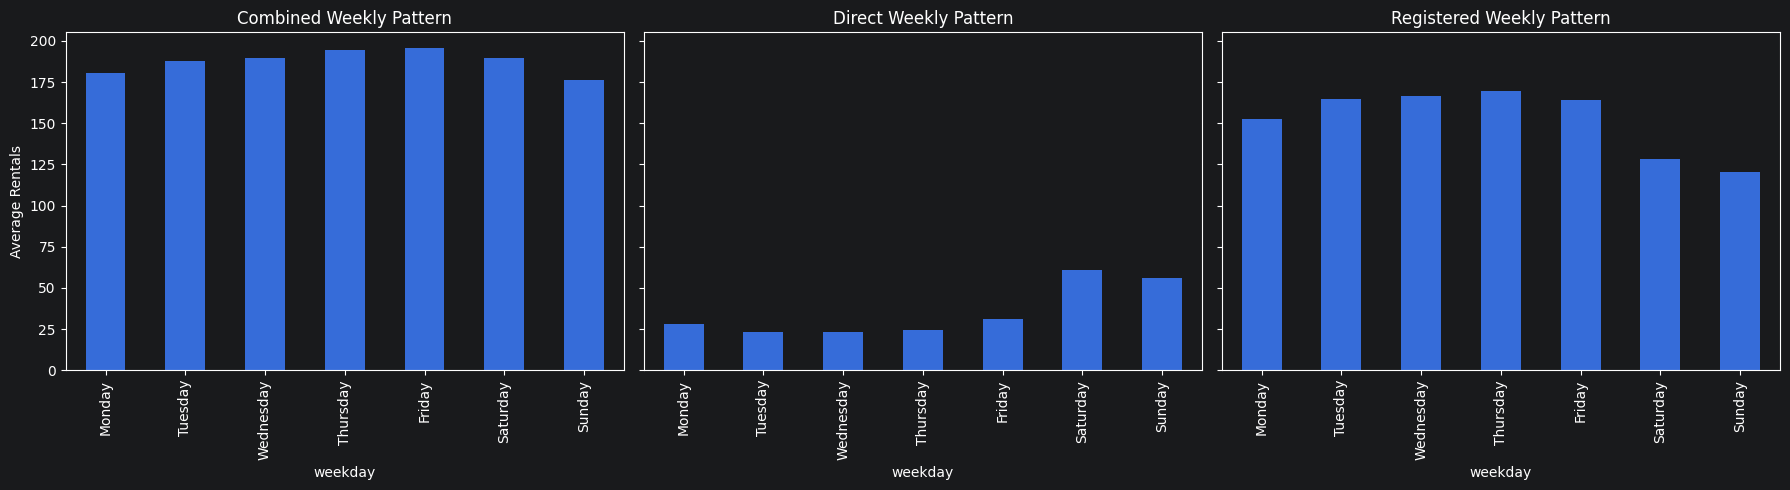

In [86]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (title, dataset) in zip(axes, datasets):
    pattern = (
        dataset.groupby("weekday")["rental_count"].mean().reindex(weekday_order)
    )

    pattern.plot(kind="bar", ax=ax)

    ax.set_title(f"{title} Weekly Pattern")
    ax.set_ylabel("Average Rentals")

plt.tight_layout()
plt.show()

# Rentals per day in a week

As expected the direct rentals spike on weekdays suggesting purpose of use to be leisure.

Whereas registered rentals are more in demand on weekdays compared to weekends but compared to direct pickups on weekends the registered rentals are still higher. This suggests the clients like to preplan than be spontaneous

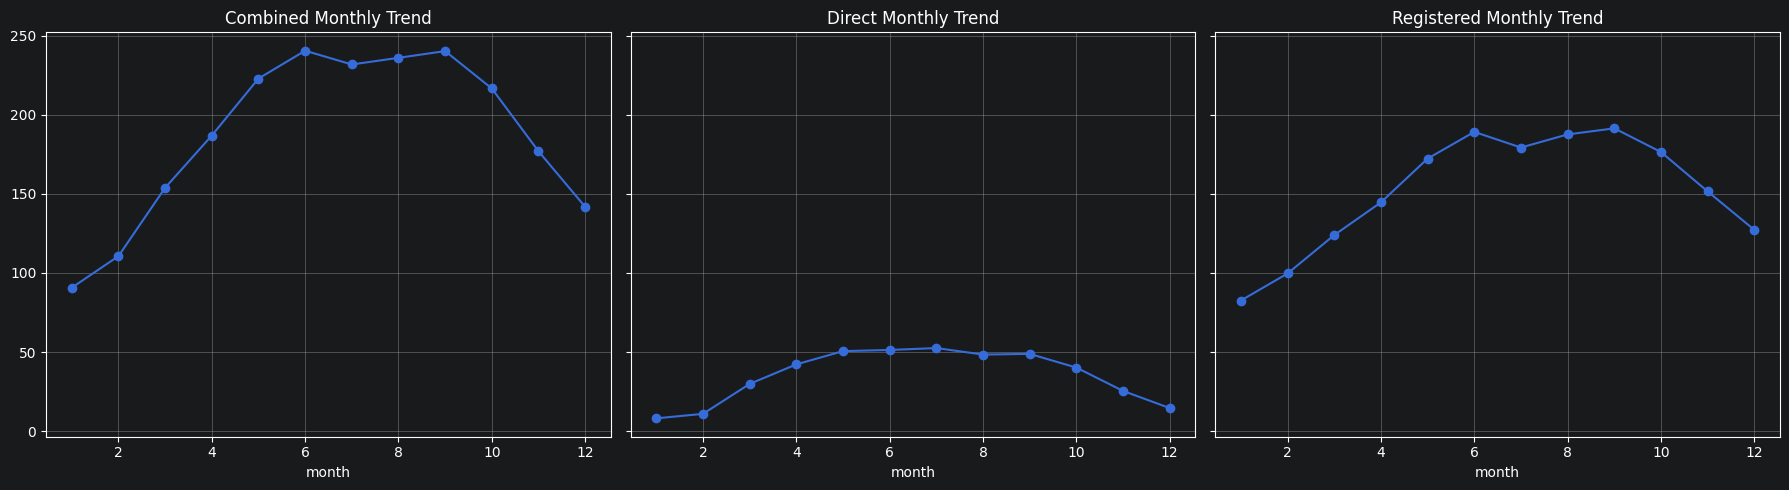

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (title, dataset) in zip(axes, datasets):
    pattern = dataset.groupby("month")["rental_count"].mean()

    pattern.plot(marker="o", ax=ax)

    ax.set_title(f"{title} Monthly Trend")
    ax.grid(True)

plt.tight_layout()
plt.show()

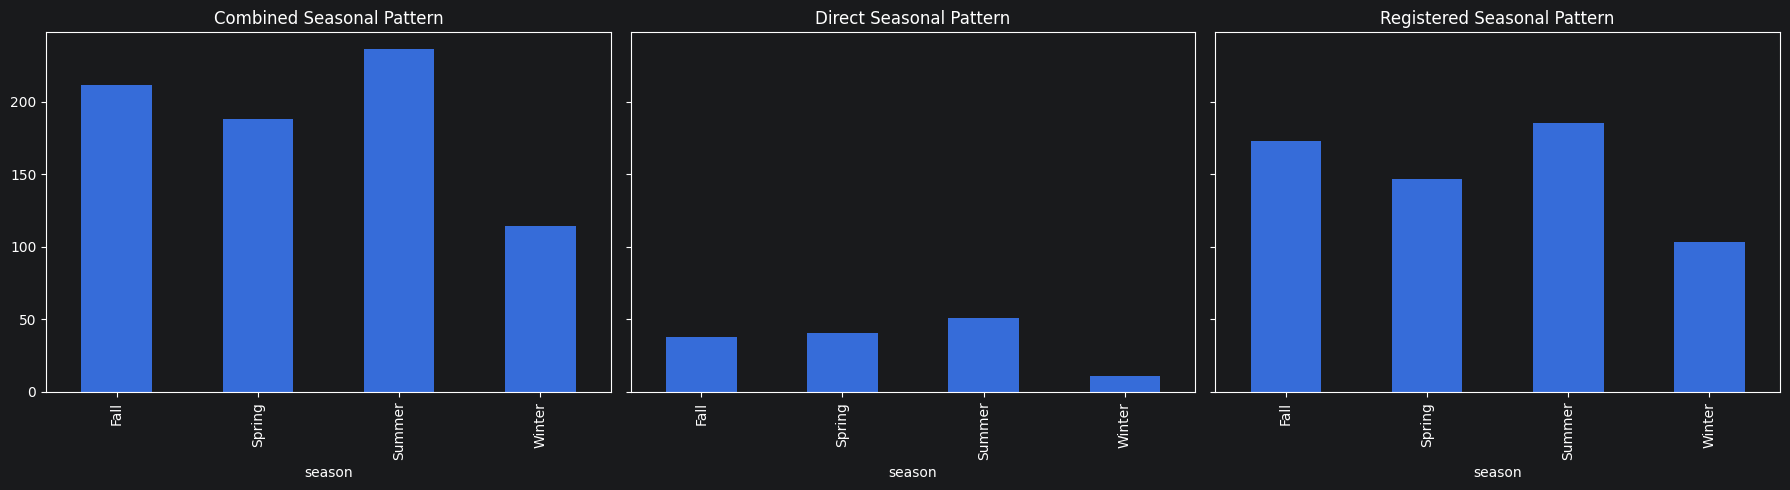

In [88]:
def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    return "Fall"


for dataset in [hourly_combined, hourly_direct, hourly_registered]:
    dataset["season"] = dataset["month"].apply(get_season)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (title, dataset) in zip(axes, datasets):
    pattern = dataset.groupby("season")["rental_count"].mean()

    pattern.plot(kind="bar", ax=ax)

    ax.set_title(f"{title} Seasonal Pattern")

plt.tight_layout()
plt.show()

# TODO
# add count and percentage for direct/total and registered/total

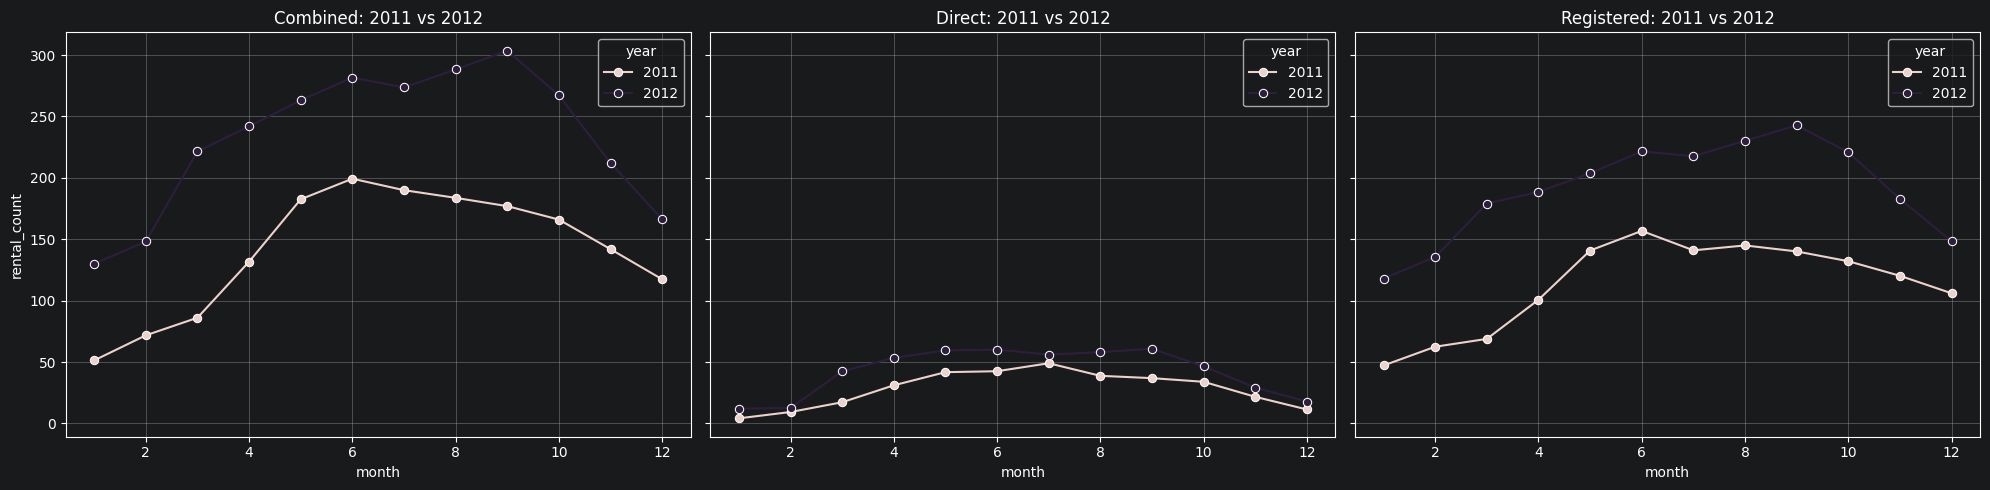

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for ax, (title, dataset) in zip(axes, datasets):
    pattern = (
        dataset.groupby(["year", "month"])["rental_count"].mean().reset_index()
    )

    sns.lineplot(
        data=pattern, x="month", y="rental_count", hue="year", marker="o", ax=ax
    )

    ax.set_title(f"{title}: 2011 vs 2012")
    ax.grid(True)

plt.tight_layout()
plt.show()

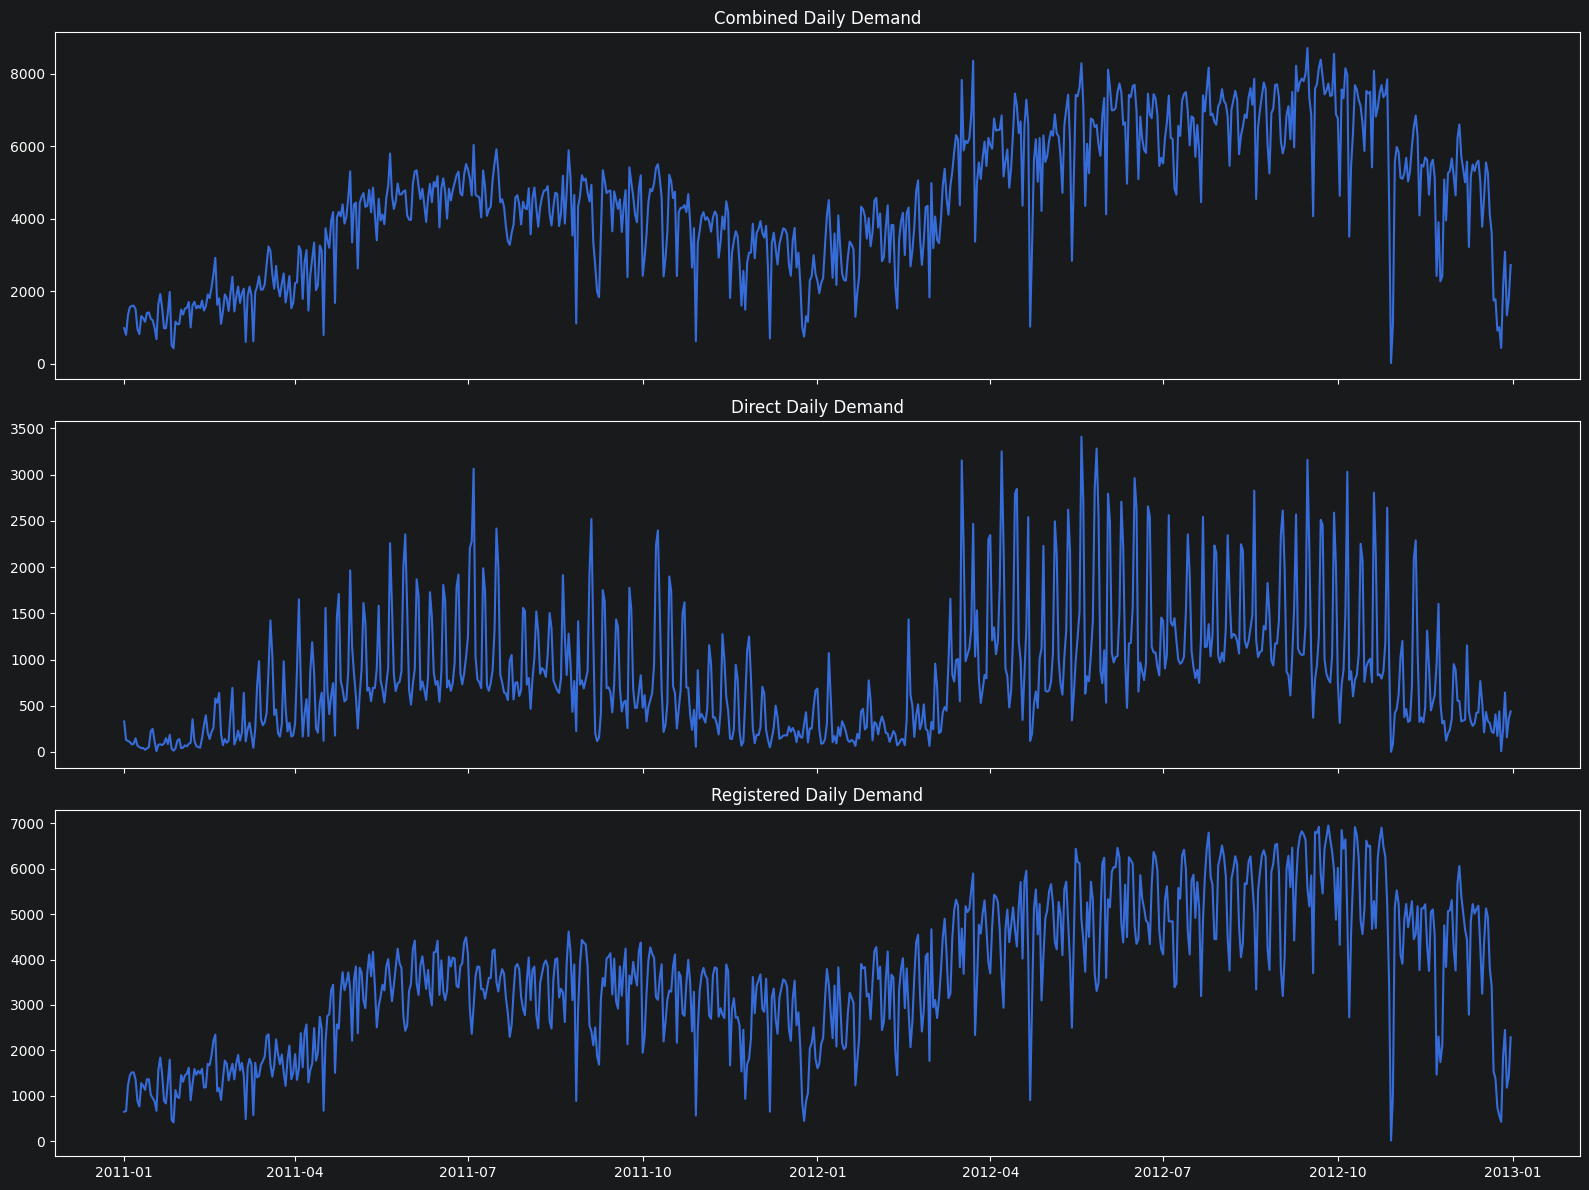

In [90]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for ax, (title, dataset) in zip(axes, datasets):
    daily = (
        dataset.groupby(dataset["datetime"].dt.date)["rental_count"]
        .sum()
        .reset_index()
    )

    daily.columns = ["date", "daily_total"]

    ax.plot(daily["date"], daily["daily_total"])

    ax.set_title(f"{title} Daily Demand")

plt.tight_layout()
plt.show()

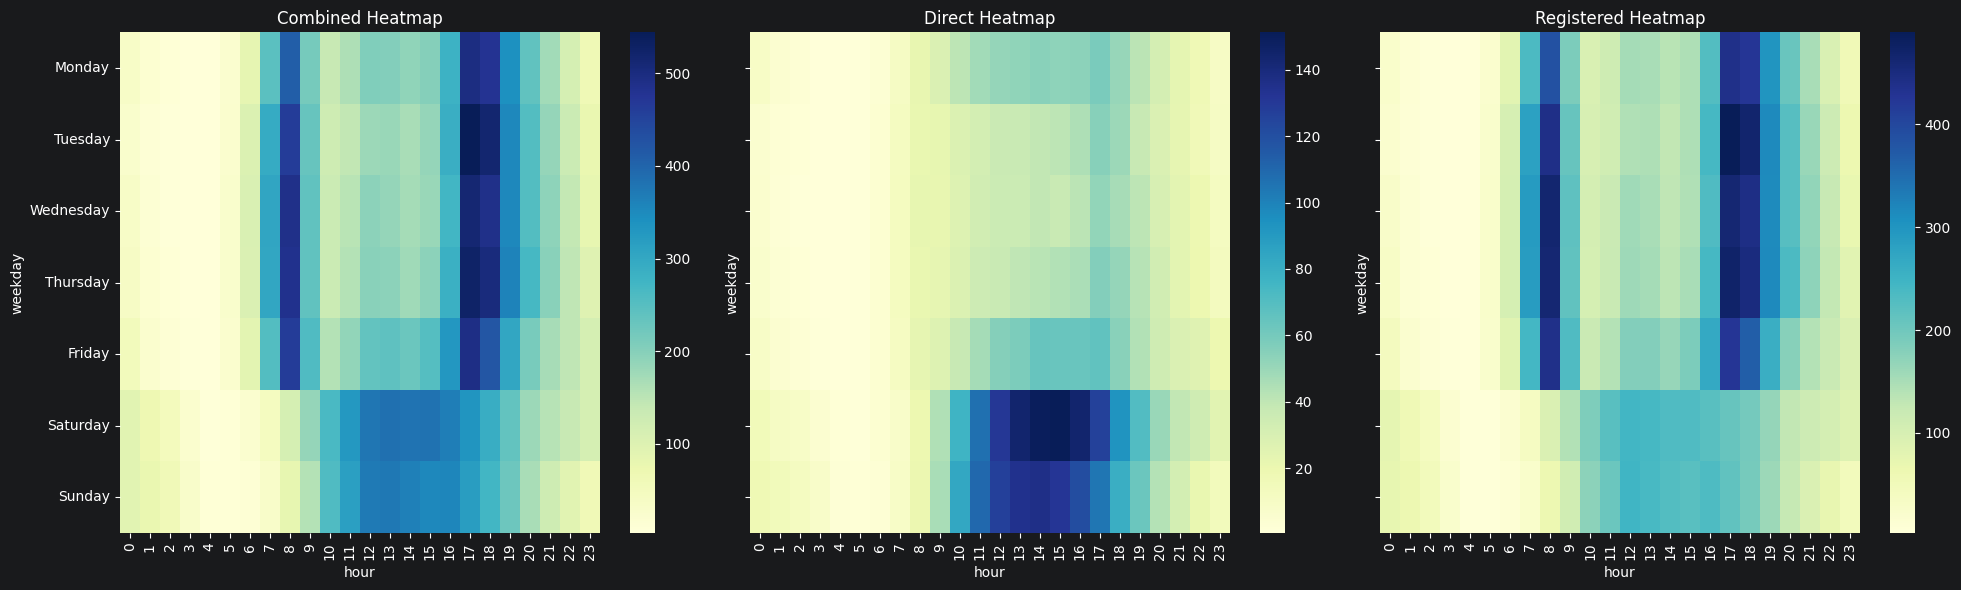

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, (title, dataset) in zip(axes, datasets):
    pivot = (
        dataset.groupby(["weekday", "hour"])["rental_count"]
        .mean()
        .reset_index()
    )

    pivot_table = pivot.pivot(
        index="weekday", columns="hour", values="rental_count"
    )

    pivot_table = pivot_table.reindex(weekday_order)

    sns.heatmap(pivot_table, cmap="YlGnBu", ax=ax)

    ax.set_title(f"{title} Heatmap")

plt.tight_layout()
plt.show()

# Conclusion on Rental Patterns

Direct rentals are people who use bikes for leisure on weekends and sometimes in the evenings to probably commute from work to home.
Registered rentals are people who use bikes on weekdays to commute to work and back.

There was an increase in the bookings from 2011 to 2012 and most of it was contributed by the people who register in advance for the bikes.



IMPORTANT NOTE :

These conclusions can be skewed because of lack of data on whether the direct pickup of bikes is relatively low because there were no available bikes and so a direct pickup was not possible and is not part of the dataset given or if the data in csv is independent of the availability of bikes and records all instances of direct pickup

# Merge weather and Holiday csv files

In [92]:
weather_df = pd.read_csv("../week-2/data/weather.csv")

print(weather_df.head())

# Convert datetime
weather_df["datetime"] = pd.to_datetime(weather_df["datetime"])

print(weather_df.dtypes)

   id             datetime conditions  temperature_c  perceived_temperature_c  \
0   1  2011-01-01 00:00:00      clear            3.3                      3.0   
1   2  2011-01-01 01:00:00      clear            2.3                      2.0   
2   3  2011-01-01 02:00:00      clear            2.3                      2.0   
3   4  2011-01-01 03:00:00      clear            3.3                      3.0   
4   5  2011-01-01 04:00:00      clear            3.3                      3.0   

   humidity  windspeed_kmh  
0      81.0            0.0  
1      80.0            0.0  
2      80.0            0.0  
3      75.0            0.0  
4      75.0            0.0  
id                                  int64
datetime                   datetime64[ns]
conditions                         object
temperature_c                     float64
perceived_temperature_c           float64
humidity                          float64
windspeed_kmh                     float64
dtype: object


In [93]:
holidays_df = pd.read_csv("../week-2/data/holidays.csv")

print(holidays_df.head())

# Convert date column
holidays_df["date"] = pd.to_datetime(holidays_df["date"])

print(holidays_df.dtypes)

   id        date                                 holiday
0   1  2011-01-17  Dr. Martin Luther King, Jr.'s Birthday
1   2  2011-02-21                   Washington's Birthday
2   3  2011-04-15        D.C. Emancipation Day (observed)
3   4  2011-05-30                            Memorial Day
4   5  2011-07-04                        Independence Day
id                  int64
date       datetime64[ns]
holiday            object
dtype: object


In [94]:
df["datetime_hour"] = df["datetime"].dt.floor("h")

print(df.head())

   id            datetime  user_id  location_id  rental_type_direct  \
0   1 2011-01-01 00:24:04      232            2                   1   
1   2 2011-01-01 00:30:19       54           14                   1   
2   3 2011-01-01 00:39:08      201            5                   1   
3   4 2011-01-01 01:01:12      298           13                   1   
4   5 2011-01-01 01:02:37       23           14                   1   

        datetime_hour  
0 2011-01-01 00:00:00  
1 2011-01-01 00:00:00  
2 2011-01-01 00:00:00  
3 2011-01-01 01:00:00  
4 2011-01-01 01:00:00  


In [95]:
weather_df["datetime_hour"] = weather_df["datetime"].dt.floor("h")

print(weather_df.head())

   id            datetime conditions  temperature_c  perceived_temperature_c  \
0   1 2011-01-01 00:00:00      clear            3.3                      3.0   
1   2 2011-01-01 01:00:00      clear            2.3                      2.0   
2   3 2011-01-01 02:00:00      clear            2.3                      2.0   
3   4 2011-01-01 03:00:00      clear            3.3                      3.0   
4   5 2011-01-01 04:00:00      clear            3.3                      3.0   

   humidity  windspeed_kmh       datetime_hour  
0      81.0            0.0 2011-01-01 00:00:00  
1      80.0            0.0 2011-01-01 01:00:00  
2      80.0            0.0 2011-01-01 02:00:00  
3      75.0            0.0 2011-01-01 03:00:00  
4      75.0            0.0 2011-01-01 04:00:00  


In [96]:
rentals_weather_df = pd.merge(
    df,
    weather_df[
        [
            "datetime_hour",
            "conditions",
            "temperature_c",
            "perceived_temperature_c",
            "humidity",
            "windspeed_kmh",
        ]
    ],
    on="datetime_hour",
    how="left",
)

print(rentals_weather_df.head())

print("\nShape:")
print(rentals_weather_df.shape)

print("\nNull counts:")
print(rentals_weather_df.isnull().sum())

   id            datetime  user_id  location_id  rental_type_direct  \
0   1 2011-01-01 00:24:04      232            2                   1   
1   2 2011-01-01 00:30:19       54           14                   1   
2   3 2011-01-01 00:39:08      201            5                   1   
3   4 2011-01-01 01:01:12      298           13                   1   
4   5 2011-01-01 01:02:37       23           14                   1   

        datetime_hour conditions  temperature_c  perceived_temperature_c  \
0 2011-01-01 00:00:00      clear            3.3                      3.0   
1 2011-01-01 00:00:00      clear            3.3                      3.0   
2 2011-01-01 00:00:00      clear            3.3                      3.0   
3 2011-01-01 01:00:00      clear            2.3                      2.0   
4 2011-01-01 01:00:00      clear            2.3                      2.0   

   humidity  windspeed_kmh  
0      81.0            0.0  
1      81.0            0.0  
2      81.0            0.0  


In [97]:
rentals_weather_df["date"] = rentals_weather_df["datetime"].dt.floor("d")

print(rentals_weather_df.head())

   id            datetime  user_id  location_id  rental_type_direct  \
0   1 2011-01-01 00:24:04      232            2                   1   
1   2 2011-01-01 00:30:19       54           14                   1   
2   3 2011-01-01 00:39:08      201            5                   1   
3   4 2011-01-01 01:01:12      298           13                   1   
4   5 2011-01-01 01:02:37       23           14                   1   

        datetime_hour conditions  temperature_c  perceived_temperature_c  \
0 2011-01-01 00:00:00      clear            3.3                      3.0   
1 2011-01-01 00:00:00      clear            3.3                      3.0   
2 2011-01-01 00:00:00      clear            3.3                      3.0   
3 2011-01-01 01:00:00      clear            2.3                      2.0   
4 2011-01-01 01:00:00      clear            2.3                      2.0   

   humidity  windspeed_kmh       date  
0      81.0            0.0 2011-01-01  
1      81.0            0.0 2011-01-0

In [98]:
final_df = pd.merge(
    rentals_weather_df, holidays_df[["date", "holiday"]], on="date", how="left"
)

print(final_df.head())

print("\nShape:")
print(final_df.shape)

print("\nNull counts:")
print(final_df.isnull().sum())

   id            datetime  user_id  location_id  rental_type_direct  \
0   1 2011-01-01 00:24:04      232            2                   1   
1   2 2011-01-01 00:30:19       54           14                   1   
2   3 2011-01-01 00:39:08      201            5                   1   
3   4 2011-01-01 01:01:12      298           13                   1   
4   5 2011-01-01 01:02:37       23           14                   1   

        datetime_hour conditions  temperature_c  perceived_temperature_c  \
0 2011-01-01 00:00:00      clear            3.3                      3.0   
1 2011-01-01 00:00:00      clear            3.3                      3.0   
2 2011-01-01 00:00:00      clear            3.3                      3.0   
3 2011-01-01 01:00:00      clear            2.3                      2.0   
4 2011-01-01 01:00:00      clear            2.3                      2.0   

   humidity  windspeed_kmh       date holiday  
0      81.0            0.0 2011-01-01     NaN  
1      81.0         

In [99]:
final_df["is_holiday"] = final_df["holiday"].notna().astype(int)
print(final_df.columns)

Index(['id', 'datetime', 'user_id', 'location_id', 'rental_type_direct',
       'datetime_hour', 'conditions', 'temperature_c',
       'perceived_temperature_c', 'humidity', 'windspeed_kmh', 'date',
       'holiday', 'is_holiday'],
      dtype='object')


In [100]:
# Check missing weather rows
print(final_df[["conditions", "temperature_c"]].isnull().sum())

# Check holiday coverage
print(final_df["is_holiday"].value_counts())

conditions       0
temperature_c    0
dtype: int64
is_holiday
0    3214244
1      78435
Name: count, dtype: int64


Conclusions

Check data consistency of weather and holiday

In [101]:
hourly_features_df = (
    final_df.groupby("datetime_hour")
    .agg(
        rental_count=("id", "count"),
        direct_rentals=("rental_type_direct", "sum"),
        registered_rentals=("rental_type_direct", lambda x: (x == 0).sum()),
        temperature_c=("temperature_c", "mean"),
        humidity=("humidity", "mean"),
        windspeed_kmh=("windspeed_kmh", "mean"),
        conditions=("conditions", "first"),
        holiday=("holiday", "first"),
        is_holiday=("is_holiday", "max"),
    )
    .reset_index()
)

print(hourly_features_df.head())

        datetime_hour  rental_count  direct_rentals  registered_rentals  \
0 2011-01-01 00:00:00            16               3                  13   
1 2011-01-01 01:00:00            40               8                  32   
2 2011-01-01 02:00:00            32               5                  27   
3 2011-01-01 03:00:00            13               3                  10   
4 2011-01-01 04:00:00             1               0                   1   

   temperature_c  humidity  windspeed_kmh conditions holiday  is_holiday  
0            3.3      81.0            0.0      clear    None           0  
1            2.3      80.0            0.0      clear    None           0  
2            2.3      80.0            0.0      clear    None           0  
3            3.3      75.0            0.0      clear    None           0  
4            3.3      75.0            0.0      clear    None           0  


Conclusions

Add weather and holiday info to aggregated rental table

Inspect the same holiday demand distribution

Does it look consistent that 2011-01-17 "Dr. Martin Luther King, Jr.'s Birthday" has same distribution for 2012-01-16,"Dr. Martin Luther King, Jr.'s Birthday"

or 2011-01-17 and 2012-01-17 have same distribution. same for 2012-01-16 and 2011-01-16

do it for every holiday


do a heatmap for all columns of the merged table

Conclusions

Finally decide on adding new features if relevant